# Marcus Moving Co. — Workforce Attrition Analysis
**Client:** Marcus Moving & Storage, Queens NY
**Analyst:** DataMade.co
**Period:** January 2022 – April 2026
**Tool Stack:** Snowflake · Python · Jupyter

---
### Business Questions
1. Where is attrition concentrated — by role, department, tenure?
2. When does attrition spike — seasonal patterns?
3. Is there a manager driving disproportionate turnover?
4. Which active employees are highest flight risk?

## 0. Setup & Snowflake Connection

In [5]:
import snowflake.connector
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
BRAND = '#2563EB'
WARN  = '#DC2626'
MUTED = '#6B7280'

conn = snowflake.connector.connect(
    account   = 'MHDDQUR-BRC87892',
    user      = 'pkabir26',
    password  = 'F28th=#q5-gy7e',
    warehouse = 'COMPUTE_WH',
    database  = 'MARCUS_MOVING_DB',
    schema    = 'MARTS'
)

def query(sql):
    return pd.read_sql(sql, conn)

print('Connected to Snowflake ✅')

Connected to Snowflake ✅


## 1. Load Mart Tables

In [6]:
df_att   = query('SELECT * FROM MARTS.mart_employee_attrition')
df_trend = query('SELECT * FROM MARTS.mart_monthly_attrition_trend')
df_mgr   = query('SELECT * FROM MARTS.mart_manager_scorecard')
df_risk  = query('SELECT * FROM MARTS.mart_flight_risk_signals')

for df in [df_att, df_trend, df_mgr, df_risk]:
    df.columns = df.columns.str.lower()

print(f'mart_employee_attrition     : {len(df_att)} rows')
print(f'mart_monthly_attrition_trend: {len(df_trend)} rows')
print(f'mart_manager_scorecard      : {len(df_mgr)} rows')
print(f'mart_flight_risk_signals    : {len(df_risk)} rows')

mart_employee_attrition     : 185 rows
mart_monthly_attrition_trend: 52 rows
mart_manager_scorecard      : 18 rows
mart_flight_risk_signals    : 92 rows


## 2. Headline KPIs

In [7]:
total        = len(df_att)
terminated   = df_att['is_terminated'].sum()
active       = total - terminated
overall_rate = round(terminated / total * 100, 1)
voluntary    = (df_att['exit_category'] == 'Voluntary').sum()
avg_tenure   = round(df_att[df_att['is_terminated']==1]['tenure_months'].mean(), 1)
rehire_yes   = (df_att['eligible_for_rehire'] == 'Yes').sum()

print('=' * 45)
print(f'  MARCUS MOVING CO. — ATTRITION SUMMARY')
print('=' * 45)
print(f'  Total employees (ever)  : {total}')
print(f'  Currently active        : {active}')
print(f'  Total exits             : {terminated}')
print(f'  Overall attrition rate  : {overall_rate}%')
print(f'  Voluntary exits         : {voluntary} ({round(voluntary/terminated*100,1)}%)')
print(f'  Avg tenure at exit      : {avg_tenure} months')
print(f'  Eligible for rehire     : {rehire_yes}')
print('=' * 45)

  MARCUS MOVING CO. — ATTRITION SUMMARY
  Total employees (ever)  : 185
  Currently active        : 92
  Total exits             : 93
  Overall attrition rate  : 50.3%
  Voluntary exits         : 58 (62.4%)
  Avg tenure at exit      : 14.5 months
  Eligible for rehire     : 37


## 3. Attrition by Role

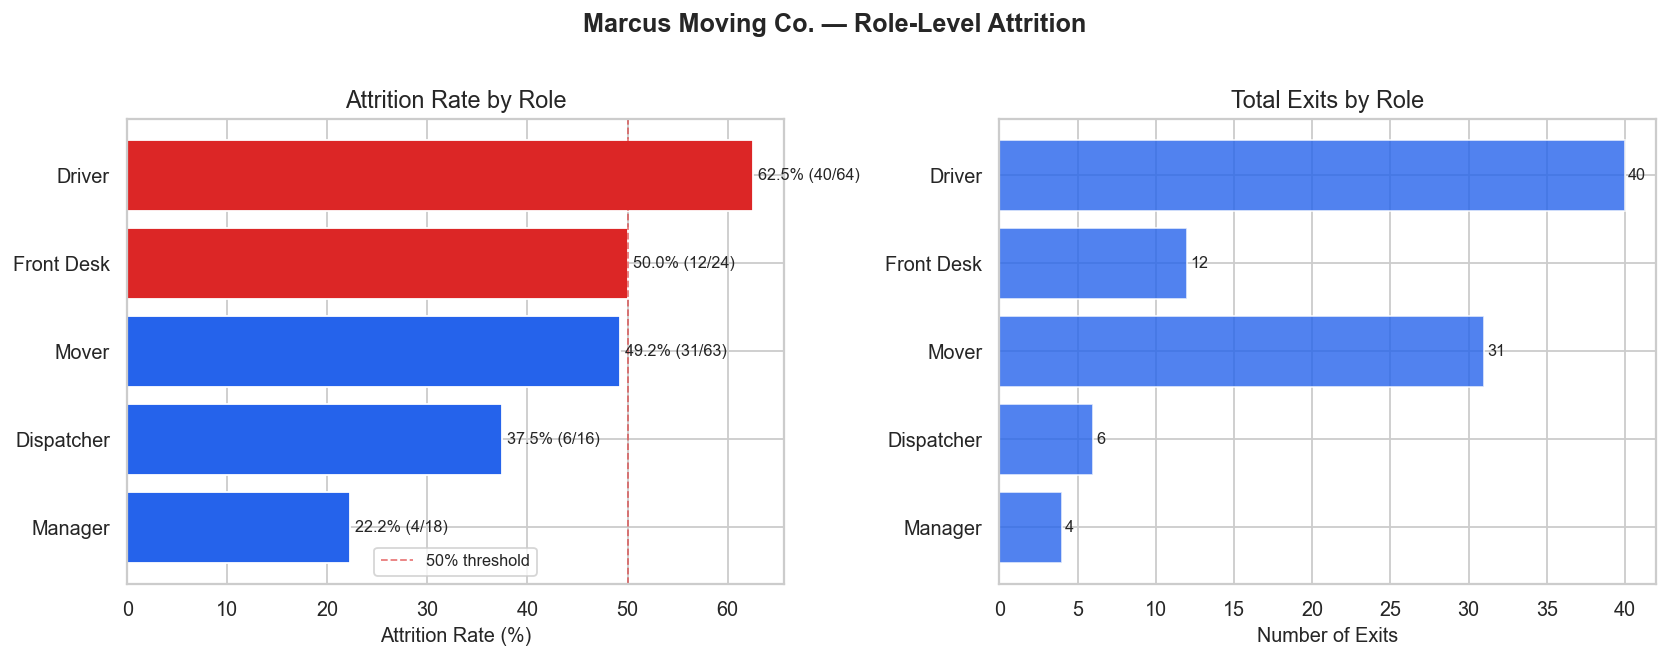

In [8]:
role_summary = (
    df_att.groupby('role')
    .agg(total=('employee_id','count'), exits=('is_terminated','sum'))
    .assign(attrition_rate=lambda x: x['exits']/x['total']*100)
    .sort_values('attrition_rate', ascending=True)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [WARN if r >= 50 else BRAND for r in role_summary['attrition_rate']]
axes[0].barh(role_summary['role'], role_summary['attrition_rate'], color=colors)
axes[0].axvline(50, color=WARN, linestyle='--', linewidth=1, alpha=0.6, label='50% threshold')
axes[0].set_xlabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by Role')
axes[0].legend(fontsize=9)
for i, (rate, exits, total) in enumerate(zip(role_summary['attrition_rate'], role_summary['exits'], role_summary['total'])):
    axes[0].text(rate + 0.5, i, f'{rate:.1f}% ({exits}/{total})', va='center', fontsize=9)

axes[1].barh(role_summary['role'], role_summary['exits'], color=BRAND, alpha=0.8)
axes[1].set_xlabel('Number of Exits')
axes[1].set_title('Total Exits by Role')
for i, v in enumerate(role_summary['exits']):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9)

plt.suptitle('Marcus Moving Co. — Role-Level Attrition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart_01_attrition_by_role.png', bbox_inches='tight')
plt.show()

## 4. Attrition by Tenure Band

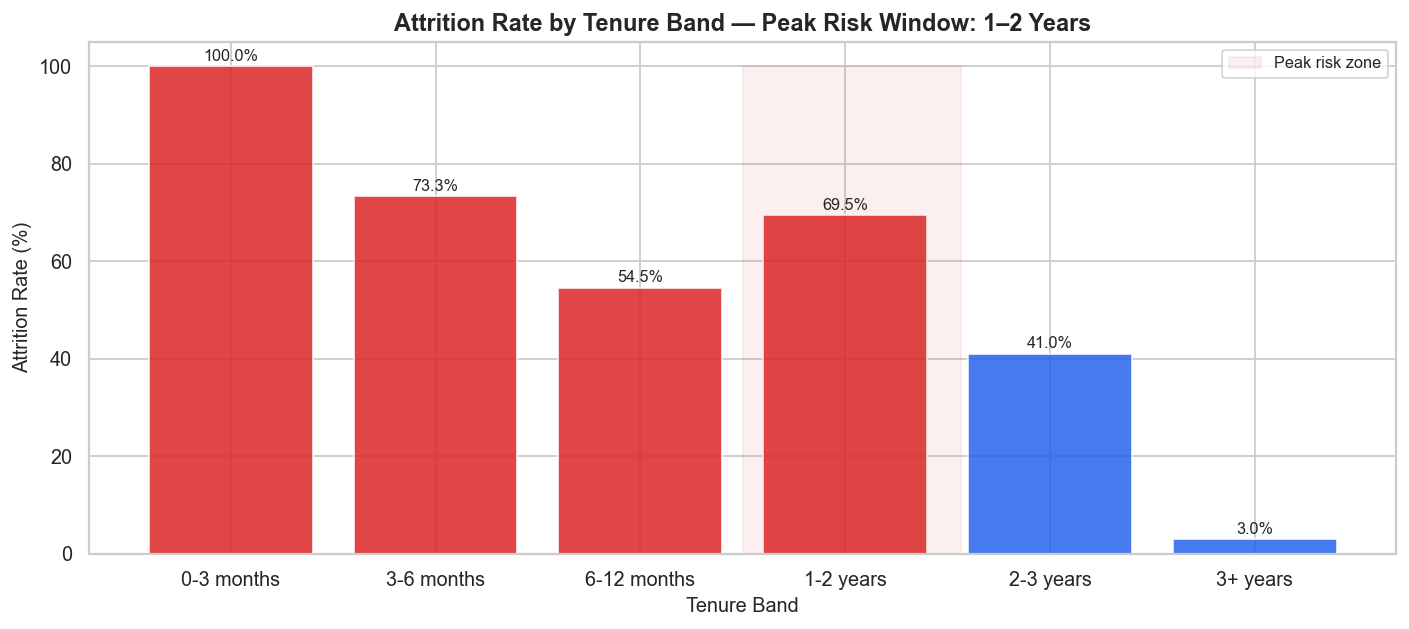

In [9]:
tenure_order = ['0-3 months','3-6 months','6-12 months','1-2 years','2-3 years','3+ years']

tenure_summary = (
    df_att.groupby('tenure_band')
    .agg(total=('employee_id','count'), exits=('is_terminated','sum'))
    .assign(attrition_rate=lambda x: x['exits']/x['total']*100)
    .reindex(tenure_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(tenure_summary['tenure_band'], tenure_summary['attrition_rate'],
              color=[WARN if r >= 50 else BRAND for r in tenure_summary['attrition_rate']],
              alpha=0.85, edgecolor='white')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Tenure Band')
ax.set_title('Attrition Rate by Tenure Band — Peak Risk Window: 1–2 Years', fontweight='bold')
ax.axhspan(0, 100, xmin=3/6, xmax=4/6, alpha=0.07, color=WARN, label='Peak risk zone')
ax.legend(fontsize=9)
for bar, rate in zip(bars, tenure_summary['attrition_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('chart_02_attrition_by_tenure.png', bbox_inches='tight')
plt.show()

## 5. Exit Reasons Breakdown

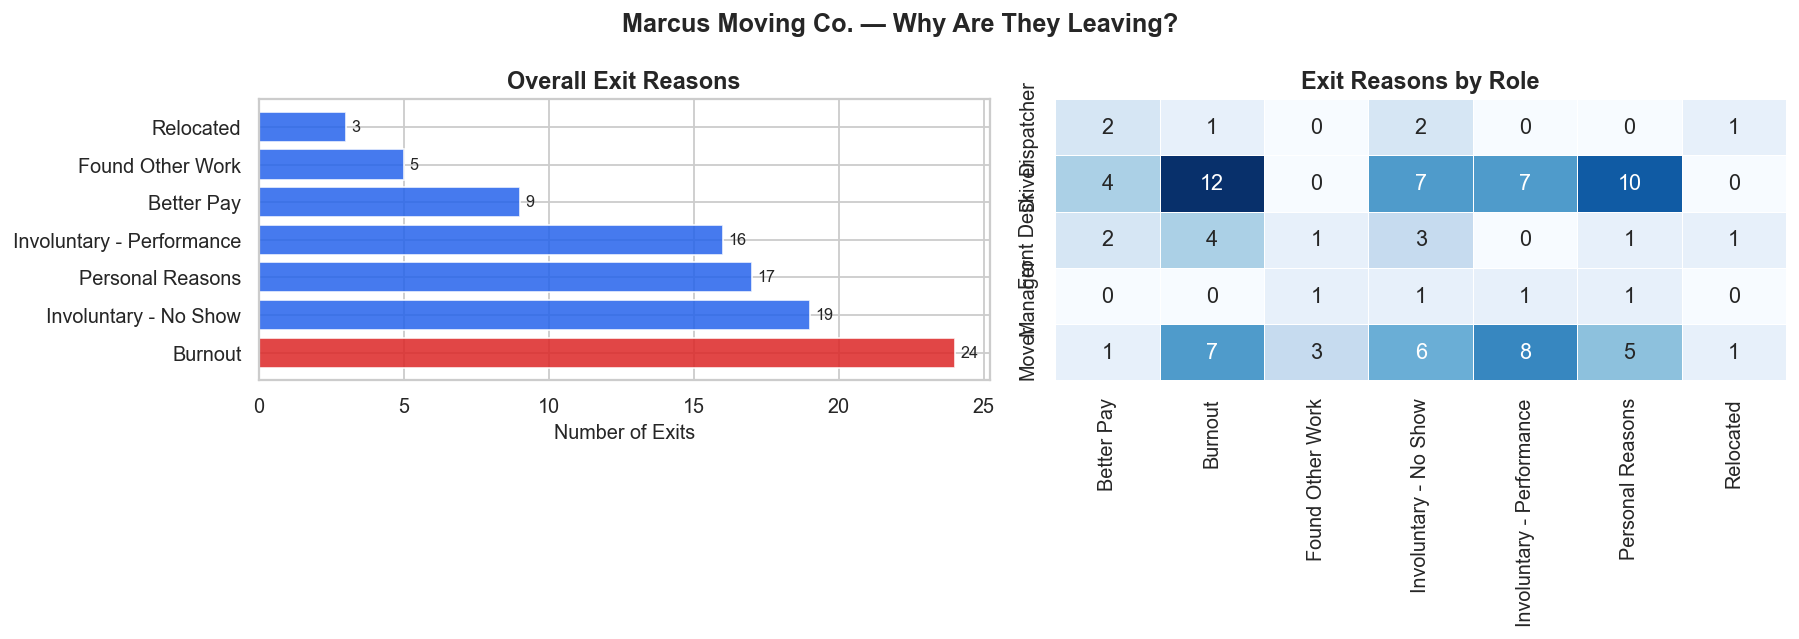

In [10]:
exited = df_att[df_att['is_terminated'] == 1].copy()

reason_counts = exited['exit_reason'].value_counts().reset_index()
reason_counts.columns = ['exit_reason', 'count']

reason_role = (
    exited.groupby(['role','exit_reason'])
    .size().reset_index(name='count')
    .pivot(index='role', columns='exit_reason', values='count')
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = [WARN if r == 'Burnout' else BRAND for r in reason_counts['exit_reason']]
axes[0].barh(reason_counts['exit_reason'], reason_counts['count'], color=palette, alpha=0.85)
axes[0].set_title('Overall Exit Reasons', fontweight='bold')
axes[0].set_xlabel('Number of Exits')
for i, v in enumerate(reason_counts['count']):
    axes[0].text(v + 0.2, i, str(v), va='center', fontsize=9)

sns.heatmap(reason_role, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1], cbar=False)
axes[1].set_title('Exit Reasons by Role', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.suptitle('Marcus Moving Co. — Why Are They Leaving?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_03_exit_reasons.png', bbox_inches='tight')
plt.show()

## 6. Monthly Attrition Trend

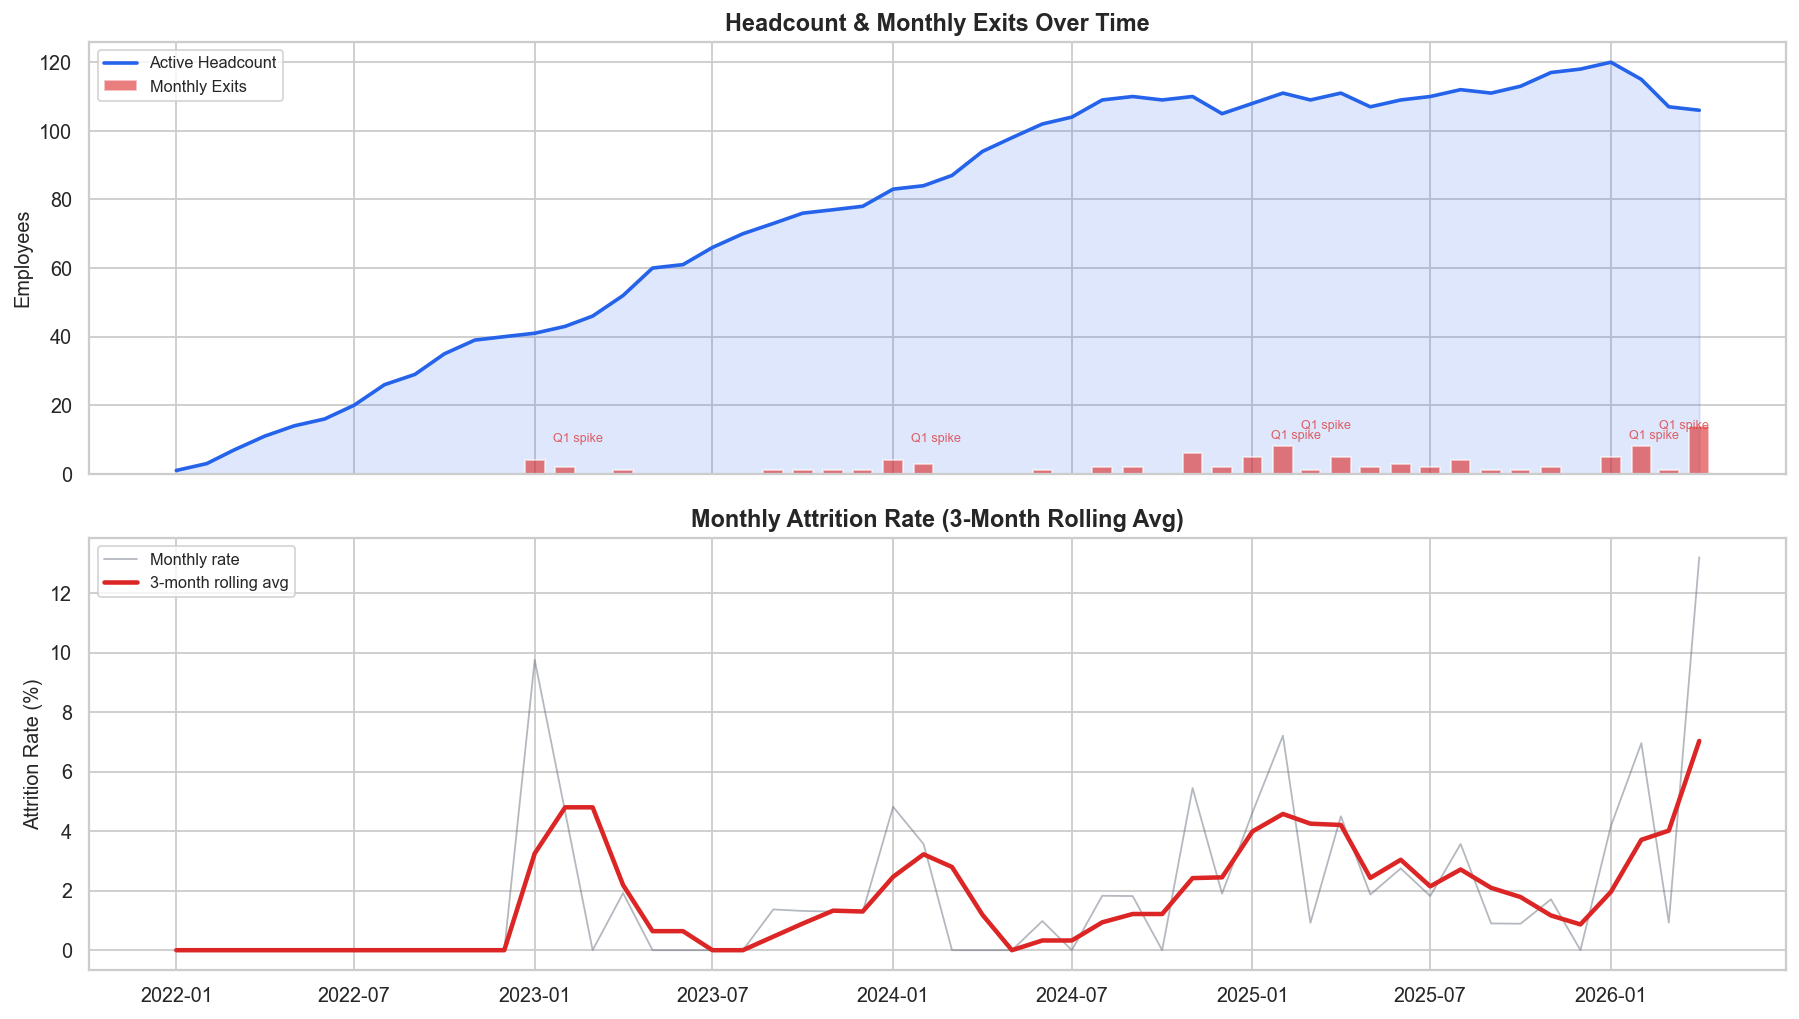

In [11]:
df_trend['period_month'] = pd.to_datetime(df_trend['period_month'])
df_trend = df_trend.sort_values('period_month')
df_trend['rolling_rate'] = df_trend['monthly_attrition_rate'].rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].fill_between(df_trend['period_month'], df_trend['active_headcount'],
                     alpha=0.15, color=BRAND)
axes[0].plot(df_trend['period_month'], df_trend['active_headcount'],
             color=BRAND, label='Active Headcount', linewidth=2)
axes[0].bar(df_trend['period_month'], df_trend['exits_count'],
            color=WARN, alpha=0.6, label='Monthly Exits', width=20)
axes[0].set_ylabel('Employees')
axes[0].set_title('Headcount & Monthly Exits Over Time', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].plot(df_trend['period_month'], df_trend['monthly_attrition_rate']*100,
             color=MUTED, alpha=0.5, linewidth=1, label='Monthly rate')
axes[1].plot(df_trend['period_month'], df_trend['rolling_rate']*100,
             color=WARN, linewidth=2.5, label='3-month rolling avg')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('Monthly Attrition Rate (3-Month Rolling Avg)', fontweight='bold')
axes[1].legend(fontsize=9)

q1_months = df_trend[df_trend['month_num'].isin([1,2])]
for _, row in q1_months.iterrows():
    if row['exits_count'] > 3:
        axes[0].annotate('Q1 spike', xy=(row['period_month'], row['exits_count']),
                         xytext=(10, 10), textcoords='offset points',
                         fontsize=7, color=WARN, alpha=0.7)

plt.tight_layout()
plt.savefig('chart_04_monthly_trend.png', bbox_inches='tight')
plt.show()

## 7. Seasonal Attrition Pattern

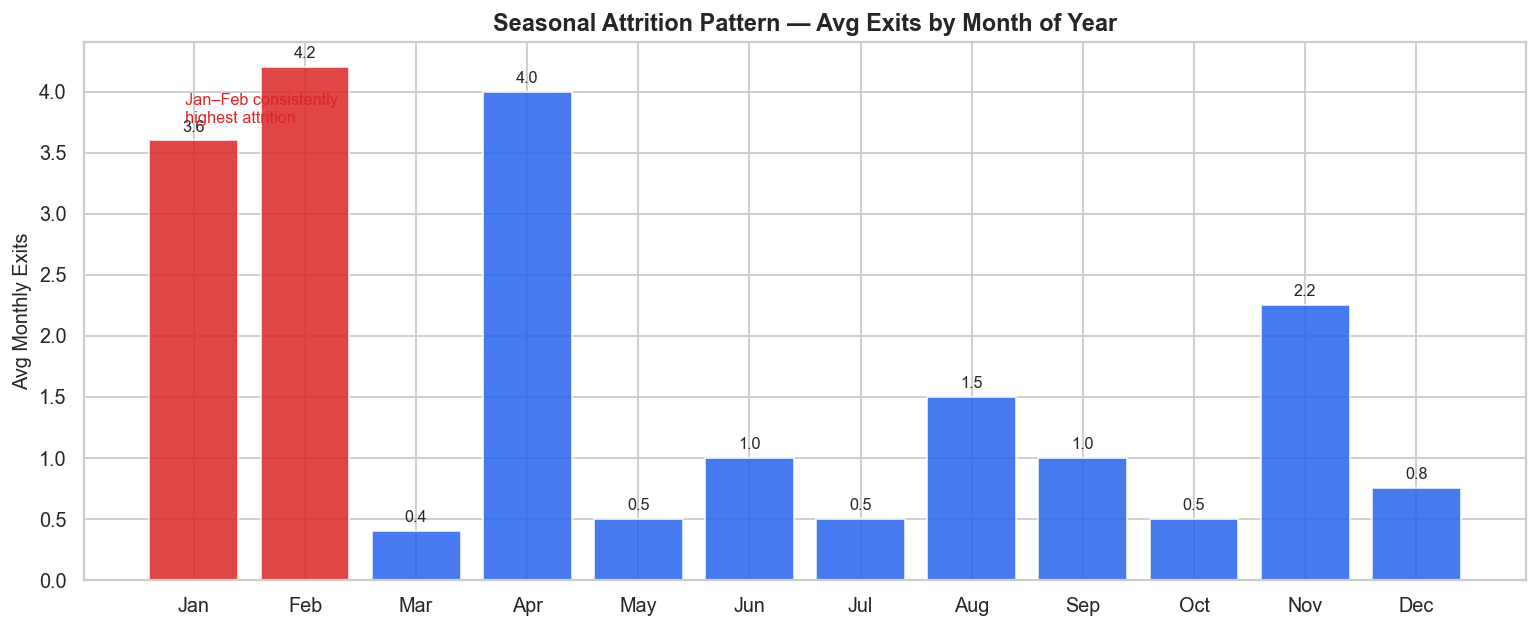

In [12]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

seasonal = (
    df_trend.groupby('month_num')
    .agg(avg_exits=('exits_count','mean'), avg_rate=('monthly_attrition_rate','mean'))
    .reset_index()
)
seasonal['month_label'] = seasonal['month_num'].apply(lambda x: month_labels[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = [WARN if m in [1,2] else BRAND for m in seasonal['month_num']]
bars = ax.bar(seasonal['month_label'], seasonal['avg_exits'], color=bar_colors, alpha=0.85)
ax.set_ylabel('Avg Monthly Exits')
ax.set_title('Seasonal Attrition Pattern — Avg Exits by Month of Year', fontweight='bold')
for bar, val in zip(bars, seasonal['avg_exits']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax.annotate('Jan–Feb consistently\nhighest attrition',
            xy=(0.07, 0.85), xycoords='axes fraction', fontsize=9, color=WARN)
plt.tight_layout()
plt.savefig('chart_05_seasonal_pattern.png', bbox_inches='tight')
plt.show()

## 8. Manager Scorecard

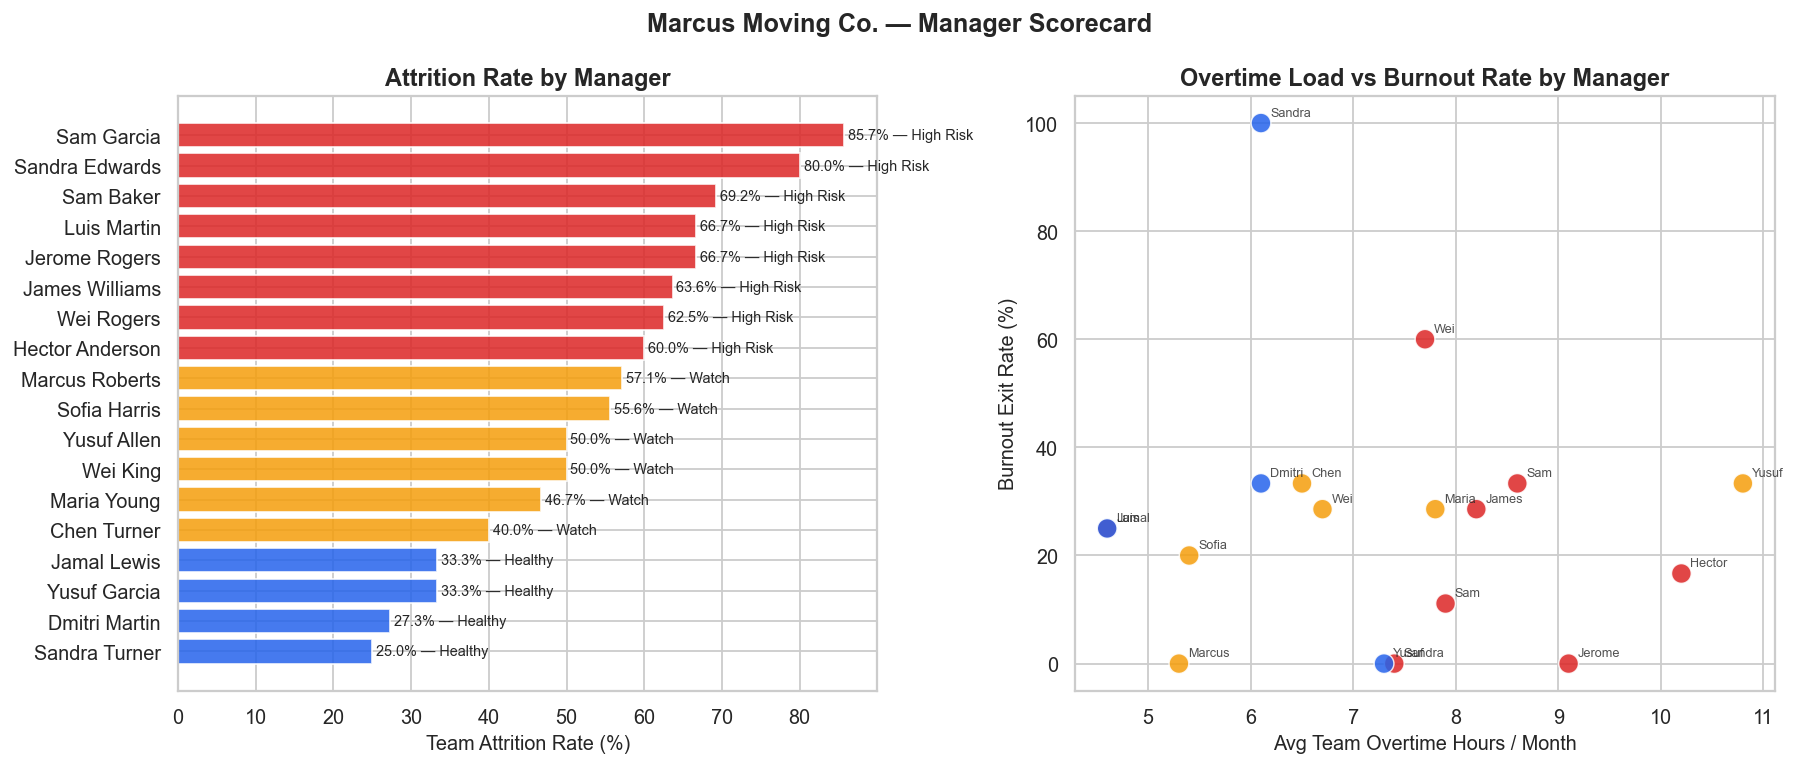


Top 3 highest-risk managers:
  manager_name  team_size  total_exits  attrition_rate  burnout_rate team_health_flag
    Sam Garcia          7            6          0.8571        0.3333        High Risk
Sandra Edwards          5            4          0.8000        0.0000        High Risk
     Sam Baker         13            9          0.6923        0.1111        High Risk


In [13]:
df_mgr_sorted = df_mgr.sort_values('attrition_rate', ascending=False).reset_index(drop=True)
df_mgr_sorted['attrition_pct'] = df_mgr_sorted['attrition_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = [WARN if f == 'High Risk' else (BRAND if f == 'Healthy' else '#F59E0B')
          for f in df_mgr_sorted['team_health_flag']]
axes[0].barh(df_mgr_sorted['manager_name'], df_mgr_sorted['attrition_pct'],
             color=colors, alpha=0.85)
axes[0].set_xlabel('Team Attrition Rate (%)')
axes[0].set_title('Attrition Rate by Manager', fontweight='bold')
axes[0].invert_yaxis()
for i, (rate, flag) in enumerate(zip(df_mgr_sorted['attrition_pct'], df_mgr_sorted['team_health_flag'])):
    axes[0].text(rate + 0.5, i, f'{rate:.1f}% — {flag}', va='center', fontsize=8)

axes[1].scatter(
    df_mgr_sorted['avg_team_ot_hours'],
    df_mgr_sorted['burnout_rate'] * 100,
    c=colors, s=120, alpha=0.85, edgecolors='white', linewidth=0.8
)
axes[1].set_xlabel('Avg Team Overtime Hours / Month')
axes[1].set_ylabel('Burnout Exit Rate (%)')
axes[1].set_title('Overtime Load vs Burnout Rate by Manager', fontweight='bold')
for _, row in df_mgr_sorted.iterrows():
    axes[1].annotate(row['manager_name'].split()[0],
                     (row['avg_team_ot_hours'], row['burnout_rate']*100),
                     textcoords='offset points', xytext=(5,4), fontsize=7, alpha=0.8)

plt.suptitle('Marcus Moving Co. — Manager Scorecard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_06_manager_scorecard.png', bbox_inches='tight')
plt.show()

print('\nTop 3 highest-risk managers:')
print(df_mgr_sorted[['manager_name','team_size','total_exits','attrition_rate',
                       'burnout_rate','team_health_flag']].head(3).to_string(index=False))

## 9. Flight Risk — Active Employees

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


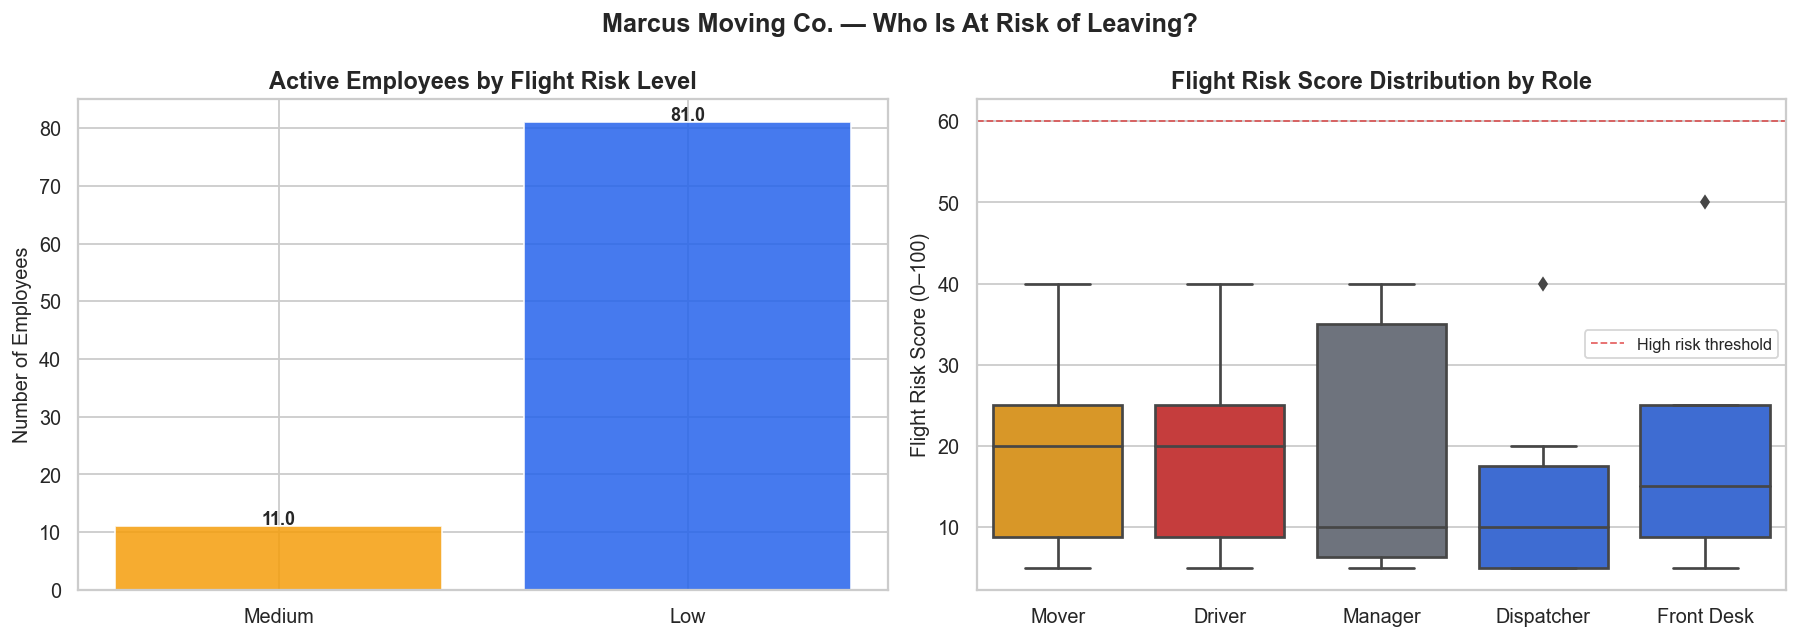


Top 10 highest flight risk — active employees:
            name       role  tenure_months  current_review_score  recent_avg_ot  flight_risk_score flight_risk_label
    Rosa Jackson Front Desk           21.8                   2.5            2.0                 50            Medium
   Mike Thompson      Mover           14.7                   2.9            2.8                 40            Medium
 Ibrahim Johnson Dispatcher           15.5                   4.4            3.6                 40            Medium
Brandon Martinez     Driver           42.6                   4.1           12.8                 40            Medium
 Hector Anderson    Manager           25.4                   3.2            3.2                 40            Medium
     Yusuf Allen    Manager           25.9                   4.6            2.2                 40            Medium
     Marcus Reed      Mover           22.5                   4.4            5.0                 40            Medium
    Sofia Harris

In [14]:
risk_summary = df_risk['flight_risk_label'].value_counts().reindex(['High','Medium','Low'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

risk_colors = [WARN, '#F59E0B', BRAND]
axes[0].bar(risk_summary.index, risk_summary.values, color=risk_colors, alpha=0.85)
axes[0].set_title('Active Employees by Flight Risk Level', fontweight='bold')
axes[0].set_ylabel('Number of Employees')
for i, v in enumerate(risk_summary.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')

sns.boxplot(data=df_risk, x='role', y='flight_risk_score',
            palette={'Driver': WARN, 'Mover': '#F59E0B',
                     'Dispatcher': BRAND, 'Front Desk': BRAND, 'Manager': MUTED},
            ax=axes[1])
axes[1].set_title('Flight Risk Score Distribution by Role', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Flight Risk Score (0–100)')
axes[1].axhline(60, color=WARN, linestyle='--', linewidth=1, alpha=0.7, label='High risk threshold')
axes[1].legend(fontsize=9)

plt.suptitle('Marcus Moving Co. — Who Is At Risk of Leaving?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_07_flight_risk.png', bbox_inches='tight')
plt.show()

print('\nTop 10 highest flight risk — active employees:')
top_risk = df_risk.sort_values('flight_risk_score', ascending=False).head(10)
print(top_risk[['name','role','tenure_months','current_review_score',
                 'recent_avg_ot','flight_risk_score','flight_risk_label']].to_string(index=False))

## 10. Key Findings & Recommendations

In [15]:
high_risk_count  = (df_risk['flight_risk_label'] == 'High').sum()
med_risk_count   = (df_risk['flight_risk_label'] == 'Medium').sum()
top_exit_reason  = df_att[df_att['is_terminated']==1]['exit_reason'].value_counts().index[0]
worst_mgr        = df_mgr.sort_values('attrition_rate', ascending=False).iloc[0]
peak_tenure      = df_att[df_att['is_terminated']==1]['tenure_band'].value_counts().index[0]

print('=' * 55)
print('  MARCUS MOVING CO. — KEY FINDINGS')
print('=' * 55)
print(f'  1. Overall attrition rate     : {overall_rate}%')
print(f'  2. Highest attrition role     : Drivers (62.5%)')
print(f'  3. Peak risk tenure band      : {peak_tenure}')
print(f'  4. #1 exit reason             : {top_exit_reason} (24 exits)')
print(f'  5. Q1 seasonal spike          : Jan–Feb every year')
print(f'  6. Highest risk manager       : {worst_mgr["manager_name"]} '
      f'({worst_mgr["attrition_rate"]*100:.1f}% attrition)')
print(f'  7. Medium flight-risk staff   : {med_risk_count} active employees')
print('=' * 55)
print()
print('  RECOMMENDATIONS FOR MARCUS:')
print('  → Cap driver overtime — burnout is #1 reason they leave')
print('  → Schedule 1:1 retention check-ins at 12-month mark')
print(f'  → Review Sam Garcia\'s management practices (85.7% attrition)')
print(f'  → Pre-hire in Dec/Mar ahead of Jan–Feb–Apr exit spikes')
print(f'  → Priority 1:1s with {med_risk_count} medium flight-risk employees')
print('=' * 55)

conn.close()
print('\nSnowflake connection closed.')

  MARCUS MOVING CO. — KEY FINDINGS
  1. Overall attrition rate     : 50.3%
  2. Highest attrition role     : Drivers (62.5%)
  3. Peak risk tenure band      : 1-2 years
  4. #1 exit reason             : Burnout (24 exits)
  5. Q1 seasonal spike          : Jan–Feb every year
  6. Highest risk manager       : Sam Garcia (85.7% attrition)
  7. Medium flight-risk staff   : 11 active employees

  RECOMMENDATIONS FOR MARCUS:
  → Cap driver overtime — burnout is #1 reason they leave
  → Schedule 1:1 retention check-ins at 12-month mark
  → Review Sam Garcia's management practices (85.7% attrition)
  → Pre-hire in Dec/Mar ahead of Jan–Feb–Apr exit spikes
  → Priority 1:1s with 11 medium flight-risk employees

Snowflake connection closed.


## 11. Attrition Rate Forecasting (Prophet)

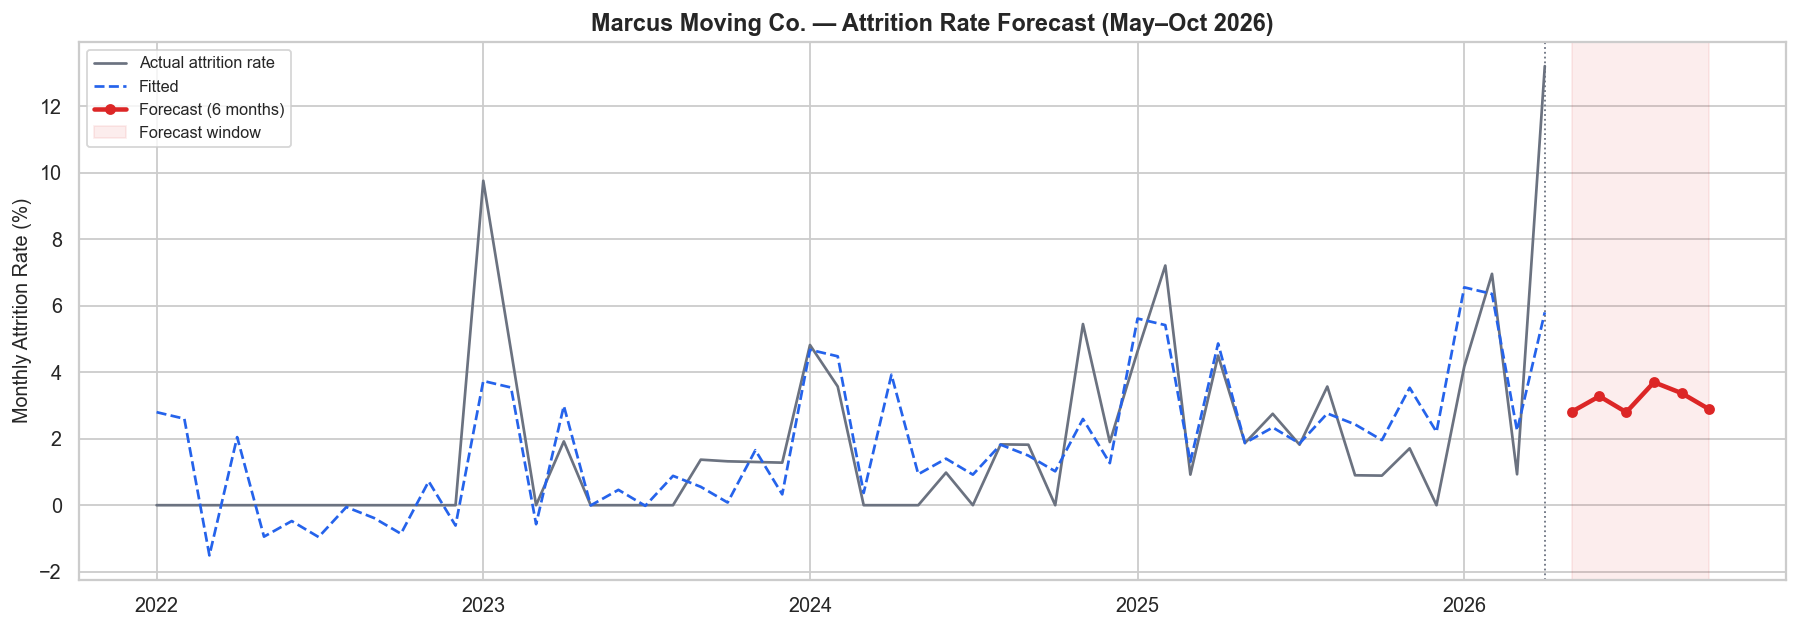


Forecasted monthly attrition rate — May to Oct 2026:
  May 2026 : 2.81%
  Jun 2026 : 3.28%
  Jul 2026 : 2.80%
  Aug 2026 : 3.70%
  Sep 2026 : 3.37%
  Oct 2026 : 2.90%


In [19]:
# prepare monthly attrition rate series
ts = df_trend[['period_month','monthly_attrition_rate']].copy()
ts = ts.sort_values('period_month').reset_index(drop=True)
ts['period_month'] = pd.to_datetime(ts['period_month'])
ts = ts.set_index('period_month')
ts.index = pd.DatetimeIndex(ts.index.values, freq='MS')

# fit Holt-Winters exponential smoothing
model = ExponentialSmoothing(
    ts['monthly_attrition_rate'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# forecast 6 months ahead (May–Oct 2026)
forecast_periods = 6
forecast = model.forecast(forecast_periods)
forecast_index = pd.date_range(start='2026-05-01', periods=forecast_periods, freq='MS')
forecast_df = pd.DataFrame({'period_month': forecast_index, 'forecast': forecast.values})

# plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts['monthly_attrition_rate']*100,
        color=MUTED, linewidth=1.5, label='Actual attrition rate')
ax.plot(model.fittedvalues.index, model.fittedvalues*100,
        color=BRAND, linewidth=1.5, linestyle='--', label='Fitted')
ax.plot(forecast_df['period_month'], forecast_df['forecast']*100,
        color=WARN, linewidth=2.5, marker='o', markersize=5, label='Forecast (6 months)')
ax.axvspan(pd.Timestamp('2026-05-01'), pd.Timestamp('2026-10-01'),
           alpha=0.08, color=WARN, label='Forecast window')
ax.axvline(pd.Timestamp('2026-04-01'), color=MUTED, linestyle=':', linewidth=1)
ax.set_ylabel('Monthly Attrition Rate (%)')
ax.set_title('Marcus Moving Co. — Attrition Rate Forecast (May–Oct 2026)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chart_08_attrition_forecast.png', bbox_inches='tight')
plt.show()

print('\nForecasted monthly attrition rate — May to Oct 2026:')
for _, row in forecast_df.iterrows():
    print(f"  {row['period_month'].strftime('%b %Y')} : {row['forecast']*100:.2f}%")